## 1. Configuración del Entorno y Mapeo Consolidado de Rutas (Fail-Safe)
Esta celda inicializa el entorno de trabajo y actúa como el motor de configuración del proyecto. Lee un archivo de control (configuracion.csv) para determinar si debe escanear el directorio físico (originals/) en busca de radiografías. De ser necesario, cruza el nombre de cada imagen con el archivo base (Data_Entry_2017.csv) para inyectar la ruta absoluta en una nueva columna, generando un dataset consolidado. Si el archivo ya existe y la configuración lo permite, omite el escaneo pesado para cargar los datos en memoria en fracciones de segundo.

In [1]:
import os
from glob import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import numpy as np

# Configuración visual global
sns.set_theme(style="whitegrid")

# --- 1. GESTIÓN DEL ARCHIVO DE CONFIGURACIÓN ---
archivo_config = 'configuracion.csv'

# Crear config por defecto si no existe
if not os.path.exists(archivo_config):
    config_data = {'label': ['regenerar_csv_rutas', 'regenerar_imagenes'], 'value': [1, 1]}
    pd.DataFrame(config_data).to_csv(archivo_config, index=False)
    print(f"[*] Archivo '{archivo_config}' creado.")

# Leer config
df_config = pd.read_csv(archivo_config)
config = dict(zip(df_config['label'], df_config['value']))
regenerar_csv_rutas = int(config.get('regenerar_csv_rutas', 1))

# --- 2. LÓGICA DE MAPEO DE RUTAS (Fail-Safe) ---
archivo_original = 'Data_Entry_2017.csv'
archivo_consolidado = 'Data_Entry_2017_con_rutas.csv'

# Condición unificada: Si el archivo no existe O la variable indica regenerar
debe_regenerar = (regenerar_csv_rutas == 1) or (not os.path.exists(archivo_consolidado))

if debe_regenerar:
    print(f"[*] Generando archivo '{archivo_consolidado}'...")
    
    # Si existe, eliminamos para recrear (limpieza completa)
    if os.path.exists(archivo_consolidado):
        os.remove(archivo_consolidado)
        print(f"[*] Archivo anterior eliminado.")

    # Escaneo
    todas_las_rutas = glob('originals/images_*/images/*.png')
    print(f"[*] Total de imágenes encontradas en disco: {len(todas_las_rutas)}")

    # Mapeo
    diccionario_rutas = {os.path.basename(ruta): ruta for ruta in todas_las_rutas}
    df_original = pd.read_csv(archivo_original)
    
    df_original['Ruta_Completa'] = df_original['Image_Index'].map(diccionario_rutas)
    df = df_original.dropna(subset=['Ruta_Completa']).copy()

    # Guardado
    df.to_csv(archivo_consolidado, index=False)
    print(f"[*] ¡Éxito! Dataset consolidado generado correctamente.")

else:
    # Caso: regenerar_csv_rutas == 0 y el archivo existe
    print(f"[*] Cargando dataset existente desde '{archivo_consolidado}'...")
    df = pd.read_csv(archivo_consolidado)

# Verificación final
display(df[['Image_Index', 'Finding_Labels', 'Patient_Age', 'Patient_Gender', 'Ruta_Completa']].head())

[*] Generando archivo 'Data_Entry_2017_con_rutas.csv'...
[*] Total de imágenes encontradas en disco: 112120
[*] ¡Éxito! Dataset consolidado generado correctamente.


,Image_Index,Finding_Labels,Patient_Age,Patient_Gender,Ruta_Completa
0,00000001_000.png,Cardiomegaly,58,M,originals/images_001/images/00000001_000.png
1,00000001_001.png,Cardiomegaly|Emphysema,58,M,originals/images_001/images/00000001_001.png
2,00000001_002.png,Cardiomegaly|Effusion,58,M,originals/images_001/images/00000001_002.png
3,00000002_000.png,No Finding,81,M,originals/images_001/images/00000002_000.png
4,00000003_000.png,Hernia,81,F,originals/images_001/images/00000003_000.png


## 2. Análisis Demográfico General (Edad y Sexo)
Esta celda realiza una limpieza inicial de valores atípicos (outliers), filtrando registros con edades inverosímiles (mayores a 100 años) para evitar sesgos visuales. A continuación, genera dos visualizaciones fundamentales: un histograma que muestra la distribución de las edades con su curva de densidad, y un gráfico de barras que cuantifica la proporción de imágenes por sexo anatómico (Masculino vs. Femenino). Este análisis permite conocer la demografía base del dataset antes de realizar los cruces de variables clínicas.

/tmp/ipykernel_1919/689990172.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_limpio, x='Patient_Gender', palette='Set2', ax=axes[1])


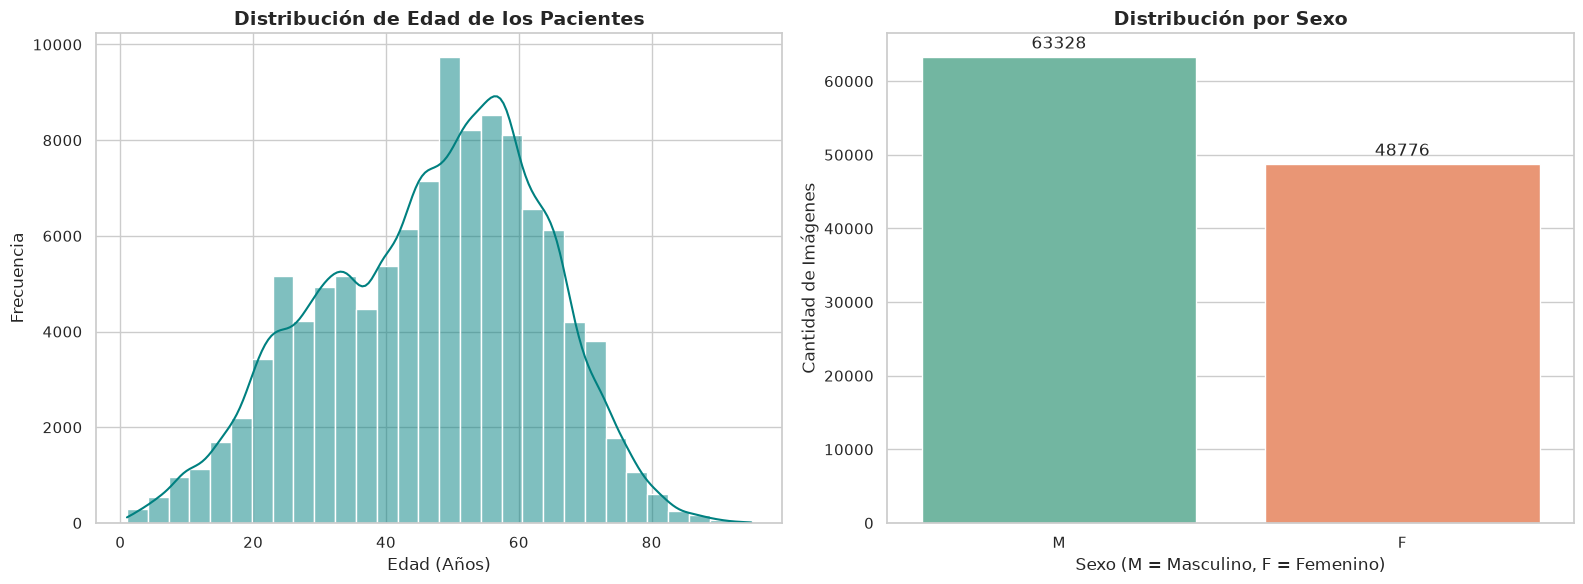

In [2]:
# 1. Filtrar edades inusuales o errores de digitación (ej. pacientes > 100 años)
df_limpio = df[df['Patient_Age'] < 100].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 2. Gráfico de Distribución de Edad
sns.histplot(df_limpio['Patient_Age'], bins=30, kde=True, ax=axes[0], color='teal')
axes[0].set_title('Distribución de Edad de los Pacientes', fontsize=14, weight='bold')
axes[0].set_xlabel('Edad (Años)', fontsize=12)
axes[0].set_ylabel('Frecuencia', fontsize=12)

# 3. Gráfico de Proporción por Sexo
sns.countplot(data=df_limpio, x='Patient_Gender', palette='Set2', ax=axes[1])
axes[1].set_title('Distribución por Sexo', fontsize=14, weight='bold')
axes[1].set_xlabel('Sexo (M = Masculino, F = Femenino)', fontsize=12)
axes[1].set_ylabel('Cantidad de Imágenes', fontsize=12)

# Añadir etiquetas de datos en las barras de sexo
for p in axes[1].patches:
    axes[1].annotate(format(p.get_height(), '.0f'), 
                     (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='center', 
                     xytext=(0, 9), textcoords='offset points')

plt.tight_layout()
plt.show()

## 2.1 Análisis Demográfico Cruzado: Patologías por Rango de Edad y Sexo
Esta celda profundiza en el Análisis Exploratorio de Datos (EDA) cruzando las variables demográficas con los hallazgos clínicos. Para no omitir información de pacientes con múltiples diagnósticos (multietiqueta), el código desglosa las patologías temporalmente, permitiendo contabilizar con precisión la frecuencia de cada enfermedad. A continuación, agrupa a los pacientes en rangos de edad (bins) de 20 años y genera visualizaciones que permiten identificar si ciertas condiciones respiratorias tienen prevalencia estadística en un género anatómico específico o en una etapa de la vida.

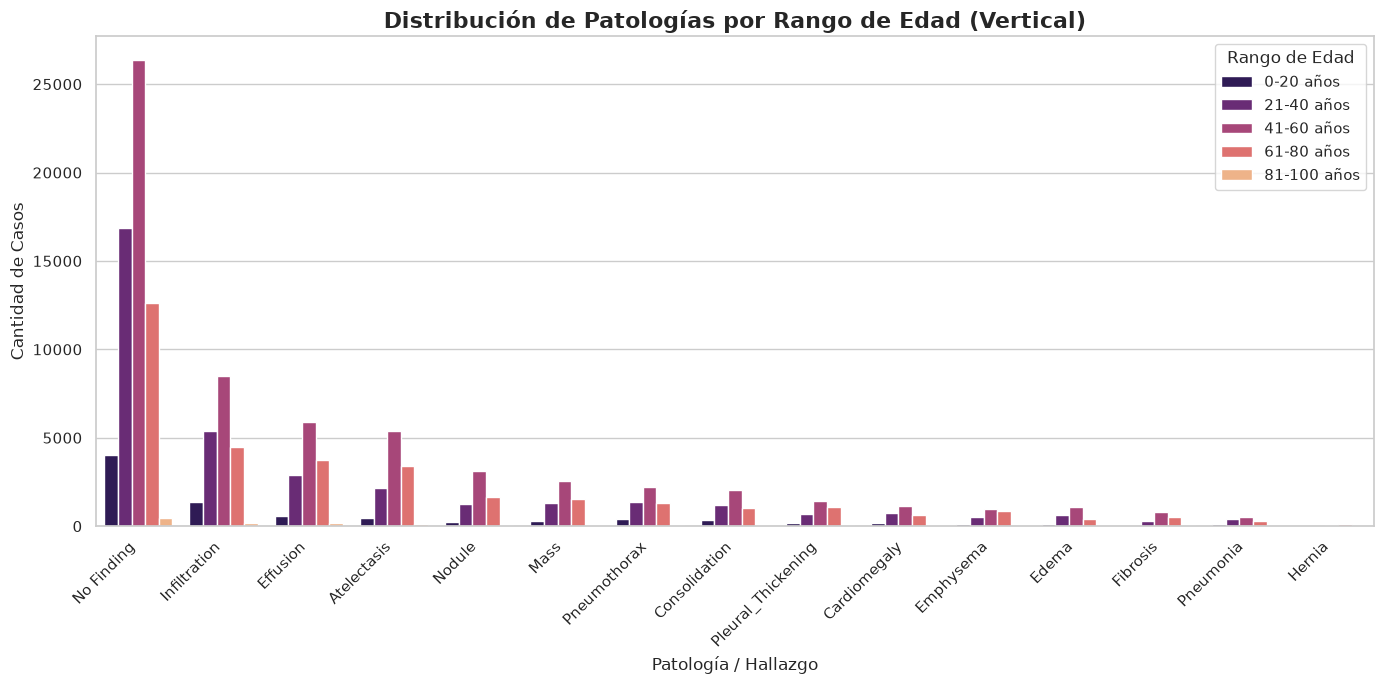

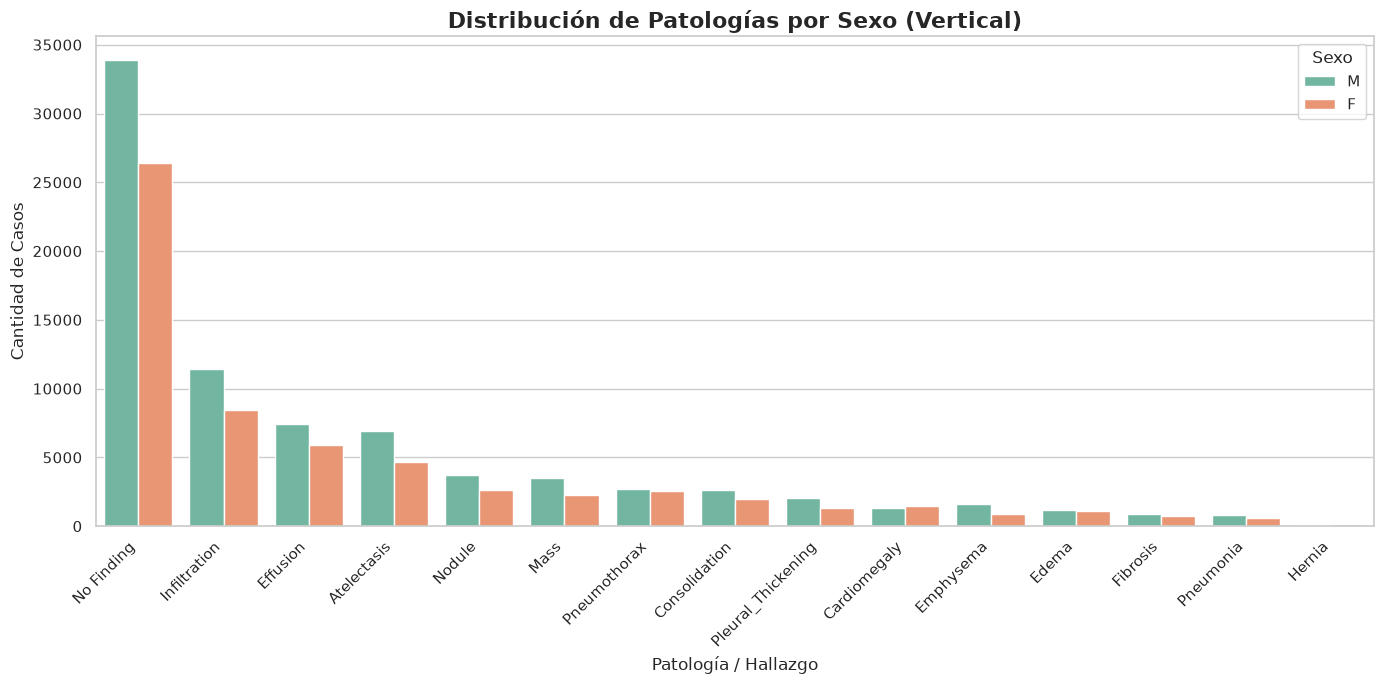

In [3]:
# 1. Desglosar las patologías múltiples
# Nota: Si ya corriste esto en otra celda, puedes omitir la línea de df_patologias
df_patologias = df_limpio.assign(Patologia=df_limpio['Finding_Labels'].str.split('|')).explode('Patologia')

# 2. Crear los rangos de edad (Bins)
bins = [0, 20, 40, 60, 80, 100]
labels = ['0-20 años', '21-40 años', '41-60 años', '61-80 años', '81-100 años']
df_patologias['Rango de Edad'] = pd.cut(df_patologias['Patient_Age'], bins=bins, labels=labels, right=False)

# 3. Gráfico Vertical
plt.figure(figsize=(14, 7))
sns.countplot(data=df_patologias, x='Patologia', hue='Rango de Edad', palette='magma',
              order=df_patologias['Patologia'].value_counts().index)

plt.title('Distribución de Patologías por Rango de Edad (Vertical)', fontsize=16, weight='bold')
plt.xlabel('Patología / Hallazgo', fontsize=12)
plt.ylabel('Cantidad de Casos', fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotación para que los nombres no se encimen
plt.legend(title='Rango de Edad', loc='upper right')

plt.tight_layout()
plt.show()

# 4. Gráfico Vertical de Sexo
plt.figure(figsize=(14, 7))
sns.countplot(data=df_patologias, x='Patologia', hue='Patient_Gender', palette='Set2',
              order=df_patologias['Patologia'].value_counts().index)

plt.title('Distribución de Patologías por Sexo (Vertical)', fontsize=16, weight='bold')
plt.xlabel('Patología / Hallazgo', fontsize=12)
plt.ylabel('Cantidad de Casos', fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotación para que los nombres no se encimen
plt.legend(title='Sexo', loc='upper right')

plt.tight_layout()
plt.show()

## 3. Análisis de Frecuencia y Mapa de Co-ocurrencia (Multietiqueta)
Esta celda transforma las etiquetas de texto en una matriz binaria (One-Hot Encoding) mediante MultiLabelBinarizer, respetando estrictamente la naturaleza multietiqueta del dataset clínico. A partir de esta matriz, se generan dos visualizaciones clave: un gráfico de barras con la frecuencia absoluta de cada hallazgo y un mapa de calor (Heatmap) de co-ocurrencia. Este mapa de calor es de altísimo valor epidemiológico, ya que revela mediante el producto punto de las matrices las comorbilidades radiológicas, es decir, qué enfermedades tienden a presentarse simultáneamente en los pacientes salvadoreños (ej. Neumonía combinada con Infiltración).

/tmp/ipykernel_1919/1944058654.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=conteo_etiquetas.index, y=conteo_etiquetas.values, palette='magma')


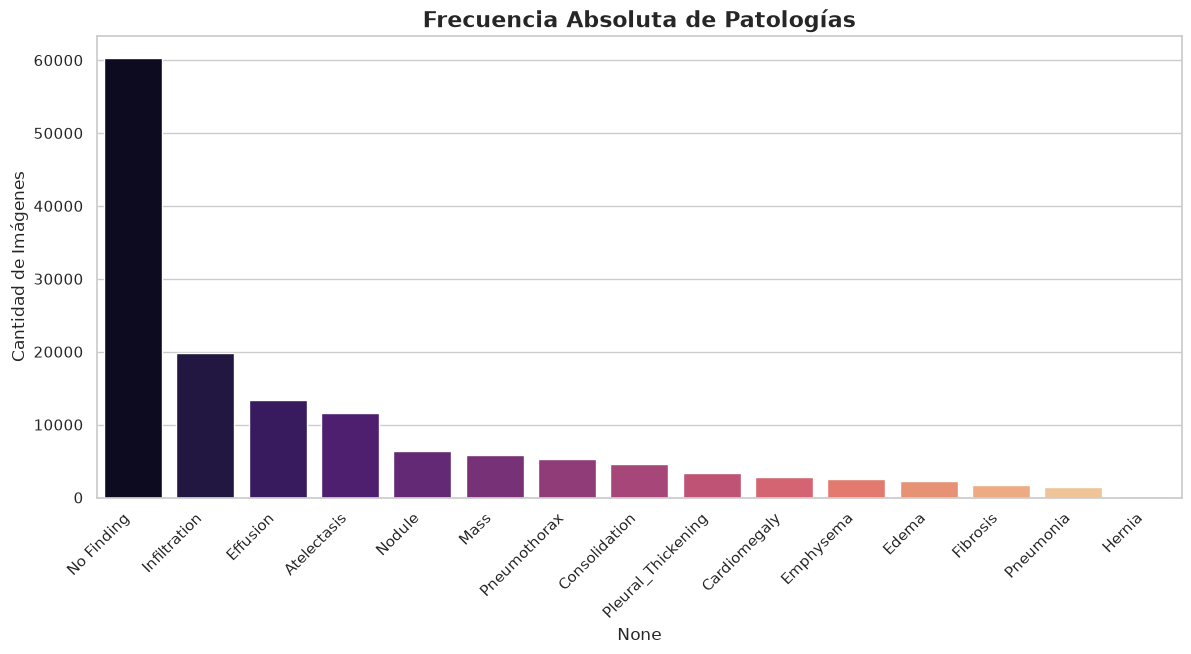

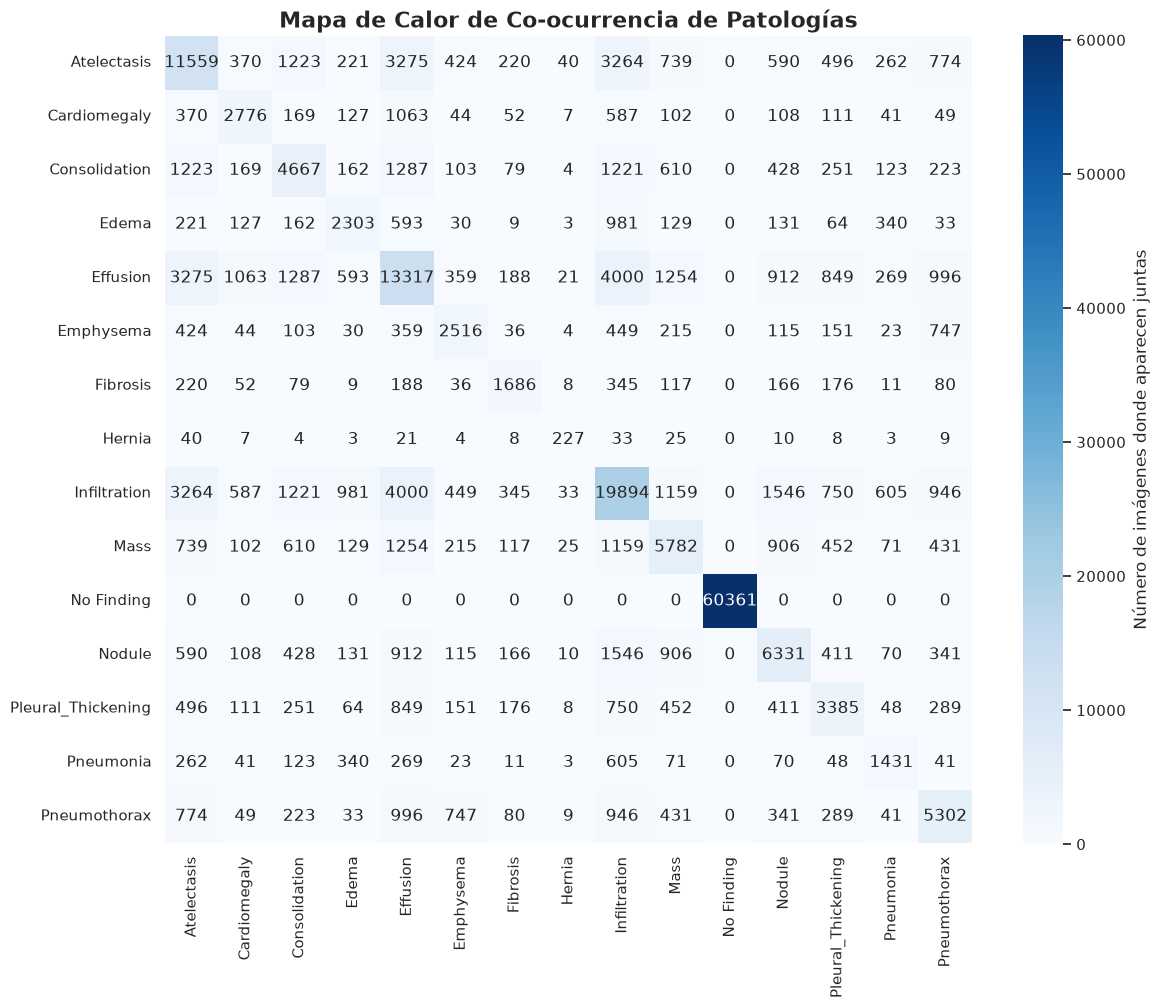

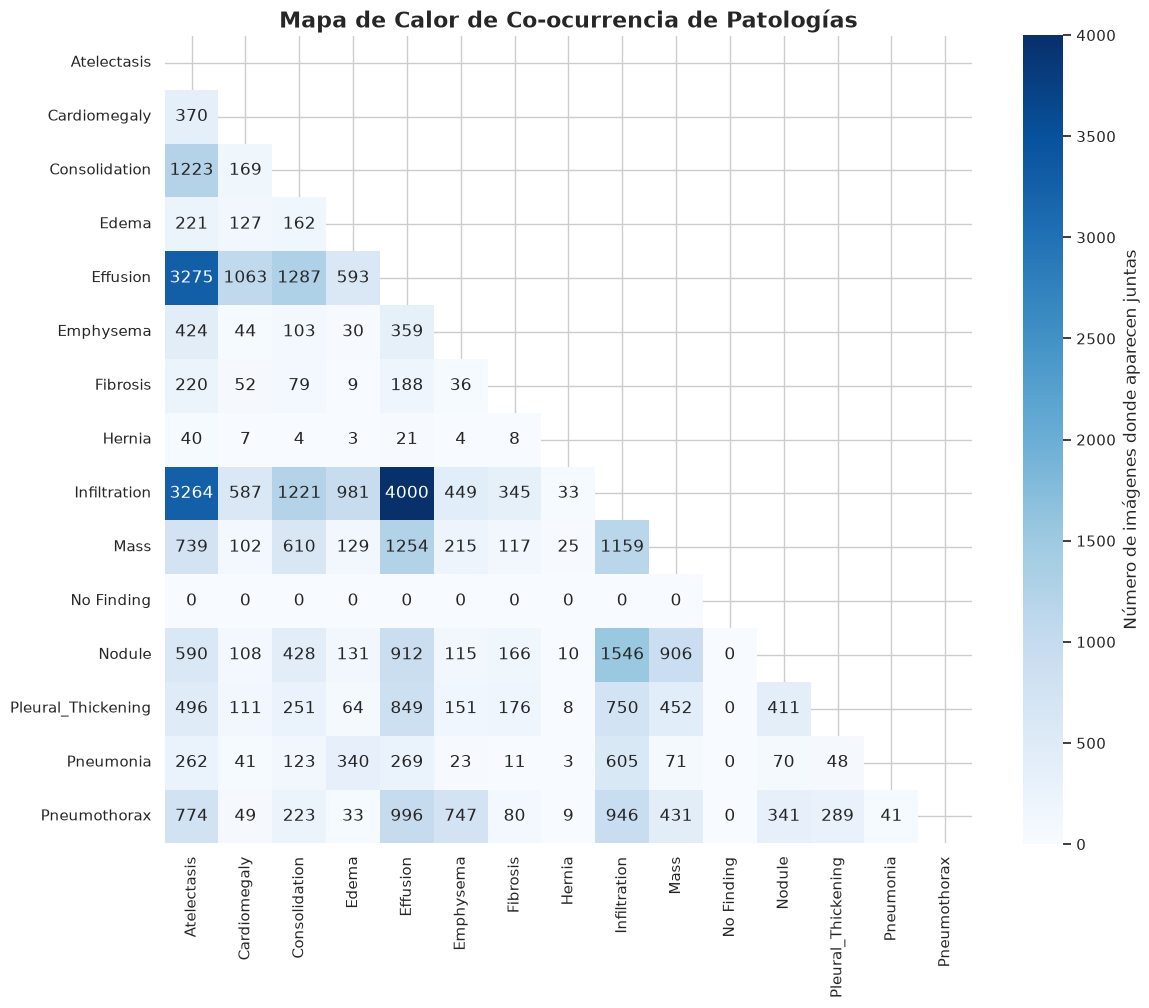

In [4]:
from sklearn.preprocessing import MultiLabelBinarizer

# 1. Preparar los datos para el análisis multietiqueta
# Separar los labels por el pipe '|' y convertirlos en listas
lista_labels = df['Finding_Labels'].apply(lambda x: x.split('|'))

# 2. Usar MultiLabelBinarizer para crear una matriz binaria (One-Hot Encoding)
mlb = MultiLabelBinarizer()
matriz_labels = mlb.fit_transform(lista_labels)
df_binario = pd.DataFrame(matriz_labels, columns=mlb.classes_)

# 3. Gráfico de Barras: Frecuencia Absoluta (Se mantiene de la versión anterior)
conteo_etiquetas = df_binario.sum().sort_values(ascending=False)

plt.figure(figsize=(14, 6))
ax = sns.barplot(x=conteo_etiquetas.index, y=conteo_etiquetas.values, palette='magma')
plt.title('Frecuencia Absoluta de Patologías', fontsize=16, weight='bold')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Cantidad de Imágenes')
plt.show()

# 4. Heatmap de Co-ocurrencia
# Calculamos la matriz de correlación (producto punto de la matriz binaria consigo misma)
co_ocurrencia = df_binario.T.dot(df_binario)

plt.figure(figsize=(12, 10))
sns.heatmap(co_ocurrencia, annot=True, fmt='d', cmap='Blues', square=True, 
            cbar_kws={'label': 'Número de imágenes donde aparecen juntas'})

plt.title('Mapa de Calor de Co-ocurrencia de Patologías', fontsize=16, weight='bold')
plt.tight_layout()
plt.show()
# 4. Heatmap de Co-ocurrencia (sin triángulo superior y sin diagonal)
co_ocurrencia = df_binario.T.dot(df_binario)

# Máscara: oculta triángulo superior + diagonal
mask = np.triu(np.ones_like(co_ocurrencia, dtype=bool), k=0)

plt.figure(figsize=(12, 10))
sns.heatmap(
    co_ocurrencia,
    mask=mask,
    annot=True,
    fmt="d",
    cmap="Blues",
    square=True,
    cbar_kws={"label": "Número de imágenes donde aparecen juntas"},
)

plt.title(
    "Mapa de Calor de Co-ocurrencia de Patologías",
    fontsize=16,
    weight="bold",
)
plt.tight_layout()
plt.show()

## 4. Visualización Estratificada: Galería de Muestras Clínicas (Multietiqueta)
Esta celda genera un panel visual dinámico (Grid) extrayendo una muestra radiológica aleatoria por cada patología única identificada en el dataset. Al procesar las etiquetas mediante segmentación (split('|')), el algoritmo asegura una representación fiel y exhaustiva de todas las condiciones clínicas, respetando los casos multietiqueta. Esta galería permite una inspección cualitativa de las imágenes, validando que el motor de lectura de archivos funciona correctamente y brindando un contexto visual indispensable antes de la fase de modelado.

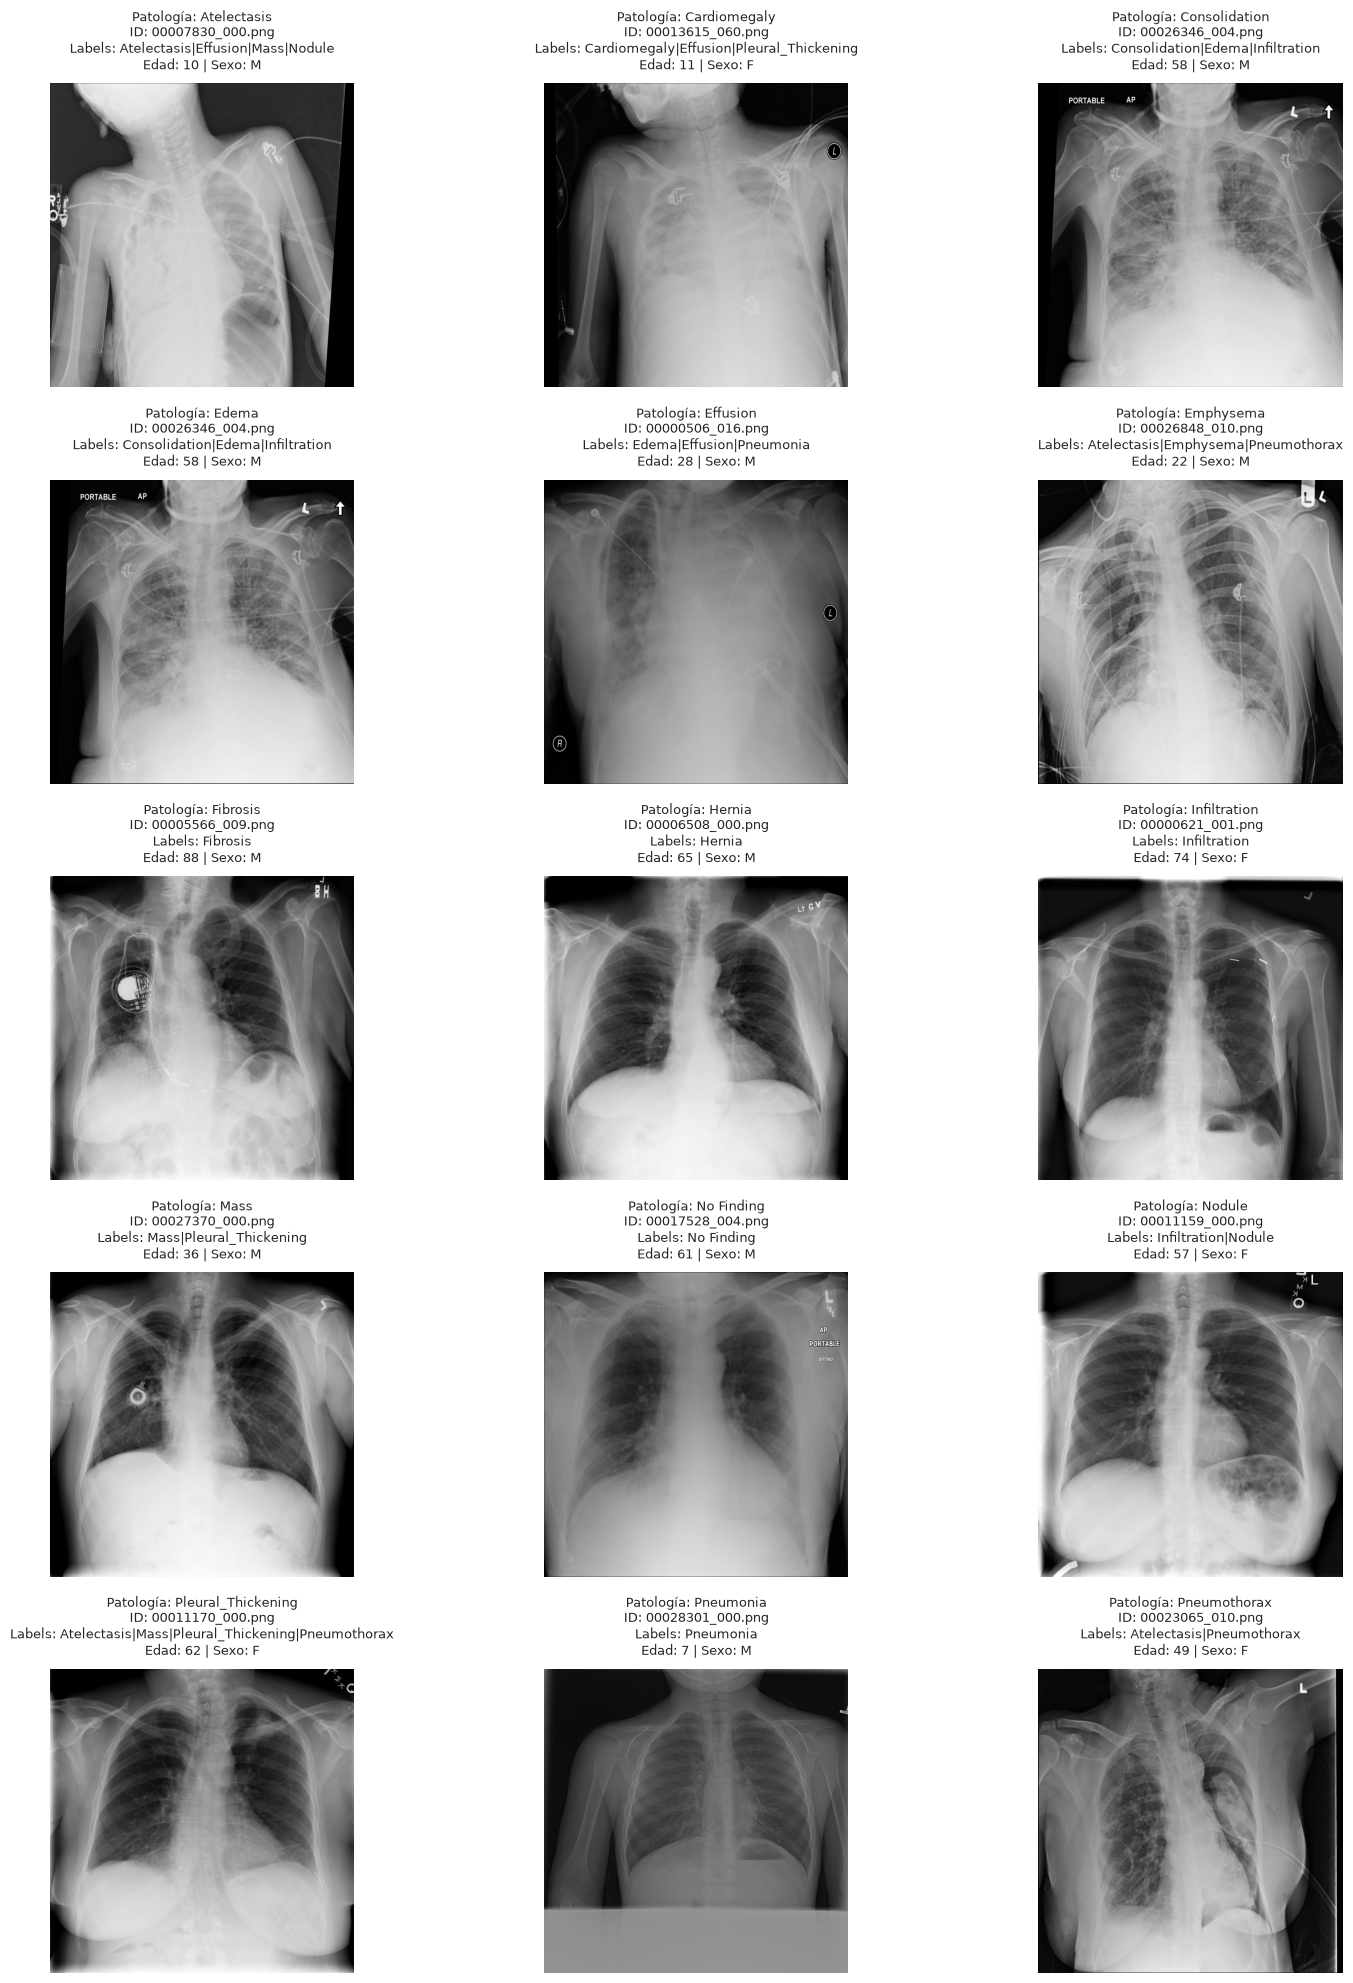

In [5]:
import math

# 1. Identificar todas las patologías únicas presentes
# Usamos explode() para separar las etiquetas en caso de multiclase (A|B)
patologias_unicas = df['Finding_Labels'].str.split('|').explode().unique()
# Opcional: ordenar alfabéticamente para que el orden sea consistente
patologias_unicas = sorted(patologias_unicas)

# 2. Configurar el layout dinámico de los subplots
num_plots = len(patologias_unicas)
cols = 3
rows = math.ceil(num_plots / cols)

fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
axes = axes.flatten()

# 3. Iterar por cada patología y seleccionar una muestra aleatoria
for i, patologia in enumerate(patologias_unicas):
    # Filtrar el dataframe para obtener todas las filas que contienen esta patología
    # Usamos .apply para buscar la patología dentro de la lista de etiquetas de cada fila
    muestras_patologia = df[df['Finding_Labels'].apply(lambda x: patologia in x.split('|'))]
    
    if not muestras_patologia.empty:
        # Seleccionar 1 muestra al azar de esta patología
        fila = muestras_patologia.sample(1).iloc[0]
        
        img_path = fila['Ruta_Completa']
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        
        if img is not None:
            axes[i].imshow(img, cmap='gray')
            
            # Título informativo
            titulo = f"Patología: {patologia}\nID: {fila['Image_Index']}\n"
            titulo += f"Labels: {fila['Finding_Labels']}\n"
            titulo += f"Edad: {fila['Patient_Age']} | Sexo: {fila['Patient_Gender']}"
            
            axes[i].set_title(titulo, fontsize=9, pad=10)
            axes[i].axis('off')
        else:
            axes[i].set_title(f"Error al cargar:\n{fila['Image_Index']}")
            axes[i].axis('off')

# 4. Ocultar los subplots que queden vacíos (si el número de patologías no llena la matriz)
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

## 5. Construcción del Dataset Maestro: Enfoque Multietiqueta, Cero Fuga de Pacientes y Preprocesamiento Híbrido
Esta celda centraliza la preparación del dataset maestro resolviendo los desafíos metodológicos más críticos del proyecto. Primero, transforma los diagnósticos a un formato multietiqueta (One-Hot Encoding) para respetar la coexistencia de patologías sin duplicar archivos, y previene la fuga de información (Patient Leakage) realizando una división estricta agrupada por paciente. Finalmente, ejecuta un preprocesamiento físico que redimensiona y almacena las imágenes en una carpeta plana unificada, integrando un motor de simulación (Proxy Scaling) diseñado para adaptar dinámicamente el volumen de datos a las restricciones reales de la investigación.

In [6]:
import os
import cv2
import pandas as pd
import numpy as np
import shutil
from sklearn.model_selection import GroupShuffleSplit
from tqdm import tqdm

# 1. Cargar configuración y datos
df_config = pd.read_csv('configuracion.csv')
config = dict(zip(df_config['label'], df_config['value']))
regenerar_imagenes = int(config.get('regenerar_imagenes', 1))

df = pd.read_csv('Data_Entry_2017_con_rutas.csv')
BASE_DIR = 'dataset_224x224_multilabel' # OJO: Ahora es una carpeta plana, sin subcarpetas
METADATA_FILE = 'dataset_multietiqueta.csv' # Nuestro nuevo CSV Maestro

# 2. Definir patologías y enfoque MULTIETIQUETA (One-Hot Encoding)
# Según el feedback del instructor: 4 neuronas de salida. Si las 4 son '0', el paciente es Sano.
patologias = ['Pneumonia', 'Effusion', 'Edema', 'Fibrosis']

for patologia in patologias:
    df[patologia] = df['Finding_Labels'].apply(lambda x: 1 if patologia in x else 0)

# Filtrar: Nos quedamos solo con las que tienen al menos una patología O son totalmente "No Finding"
mask_tiene_patologia = df[patologias].sum(axis=1) > 0
mask_es_sano = df['Finding_Labels'] == 'No Finding'
df_filtrado = df[mask_tiene_patologia | mask_es_sano].copy()

# Columna auxiliar para identificar fácilmente a los sanos en el simulador
df_filtrado['Es_Sano'] = (df_filtrado[patologias].sum(axis=1) == 0).astype(int)
df_filtrado = df_filtrado.reset_index(drop=True)

# 3. --- LABORATORIO DE SIMULACIÓN (PROXY SCALING) ---
simular_desbalance = int(config.get('simular_desbalance', 0))
total_simulacion = int(config.get('total_simulacion', 3000))
ratio_sanas = float(config.get('ratio_sanas', 0.66))

if simular_desbalance == 1:
    print(f"[*] SIMULADOR ACTIVO: Restringiendo dataset a {total_simulacion} imágenes...")
    
    sanas_imgs = df_filtrado[df_filtrado['Es_Sano'] == 1]['Image_Index'].unique()
    enfermas_imgs = df_filtrado[df_filtrado['Es_Sano'] == 0]['Image_Index'].unique()
    
    tope_sanas = int(total_simulacion * ratio_sanas)
    tope_enfermas = total_simulacion - tope_sanas
    
    np.random.seed(42)
    sanas_muestra = np.random.choice(sanas_imgs, min(tope_sanas, len(sanas_imgs)), replace=False)
    enfermas_muestra = np.random.choice(enfermas_imgs, min(tope_enfermas, len(enfermas_imgs)), replace=False)
    
    imagenes_simulacion = np.concatenate([sanas_muestra, enfermas_muestra])
    df_filtrado = df_filtrado[df_filtrado['Image_Index'].isin(imagenes_simulacion)].copy()
    df_filtrado = df_filtrado.reset_index(drop=True)
    print(f"[*] -> Muestra extraída: {len(sanas_muestra)} Sanas y {len(enfermas_muestra)} con Patologías.")
# -------------------------------------------------------------

# 4. Lógica de Regeneración y DIVISIÓN POR PACIENTE
if regenerar_imagenes == 1 or not os.path.exists(BASE_DIR) or not os.path.exists(METADATA_FILE):
    print("[*] Configuración (1): Iniciando división por paciente y redimensionamiento...")
    
    # A. Separar Train (70%) y Temp (30%) agrupando estrictamente por Patient_ID
    gss_train = GroupShuffleSplit(n_splits=1, train_size=0.70, random_state=42)
    train_idx, temp_idx = next(gss_train.split(df_filtrado, groups=df_filtrado['Patient_ID']))
    
    train_df = df_filtrado.iloc[train_idx].copy()
    temp_df = df_filtrado.iloc[temp_idx].copy()
    
    # B. Separar Temp en Val (15%) y Test (15%) agrupando estrictamente por Patient_ID
    gss_val = GroupShuffleSplit(n_splits=1, train_size=0.50, random_state=42)
    val_idx, test_idx = next(gss_val.split(temp_df, groups=temp_df['Patient_ID']))
    
    val_df = temp_df.iloc[val_idx].copy()
    test_df = temp_df.iloc[test_idx].copy()
    
    # Asignar etiquetas
    train_df['Conjunto'] = 'train'
    val_df['Conjunto'] = 'val'
    test_df['Conjunto'] = 'test'
    
    df_final = pd.concat([train_df, val_df, test_df])
    
    # --- VALIDACIÓN DEL INSTRUCTOR (Aserciones de Seguridad) ---
    train_patients = set(train_df['Patient_ID'])
    val_patients = set(val_df['Patient_ID'])
    test_patients = set(test_df['Patient_ID'])
    
    assert train_patients.isdisjoint(val_patients), "ERROR: Fuga de pacientes Train-Val"
    assert train_patients.isdisjoint(test_patients), "ERROR: Fuga de pacientes Train-Test"
    assert val_patients.isdisjoint(test_patients), "ERROR: Fuga de pacientes Val-Test"
    print("[*] Validación de seguridad superada: CERO fuga de pacientes entre conjuntos.")
    # -----------------------------------------------------------

    # 5. Procesamiento físico (CARPETA PLANA)
    if os.path.exists(BASE_DIR):
        shutil.rmtree(BASE_DIR)
        print(f"[*] Carpeta '{BASE_DIR}' eliminada para una regeneración limpia.")
    os.makedirs(BASE_DIR, exist_ok=True)
    
    errores = 0
    rutas_ligeras = []
    
    for _, fila in tqdm(df_final.iterrows(), total=len(df_final), desc="Procesando imágenes a 224x224"):
        ruta_origen = fila['Ruta_Completa']
        # Todas las imágenes van a la misma carpeta, sin importar su diagnóstico
        ruta_destino = os.path.join(BASE_DIR, fila['Image_Index'])
        rutas_ligeras.append(ruta_destino)
        
        if not os.path.exists(ruta_destino):
            img = cv2.imread(ruta_origen, cv2.IMREAD_GRAYSCALE)
            if img is not None:
                img_resized = cv2.resize(img, (224, 224), interpolation=cv2.INTER_CUBIC)
                cv2.imwrite(ruta_destino, img_resized)
            else:
                errores += 1
                
    if errores > 0:
        print(f"[*] Advertencia: Hubo {errores} imágenes ilegibles.")
        
    # Añadimos la ruta de la nueva imagen ligera y guardamos el CSV maestro
    df_final['Ruta_Ligera'] = rutas_ligeras
    df_final.to_csv(METADATA_FILE, index=False)
    print(f"[*] Archivo maestro multietiqueta '{METADATA_FILE}' generado con éxito.")

else:
    print(f"[*] Configuración (0): Cargando metadatos existentes desde '{METADATA_FILE}'...")
    df_final = pd.read_csv(METADATA_FILE)

# Resumen final Multietiqueta
print("\nResumen de imágenes preprocesadas por conjunto:")
resumen = df_final.groupby('Conjunto')[patologias].sum()
resumen['Total Sanas (0 en todas)'] = df_final[df_final['Es_Sano'] == 1].groupby('Conjunto').size()
display(resumen)

[*] SIMULADOR ACTIVO: Restringiendo dataset a 5000 imágenes...
[*] -> Muestra extraída: 2000 Sanas y 3000 con Patologías.
[*] Configuración (1): Iniciando división por paciente y redimensionamiento...
[*] Validación de seguridad superada: CERO fuga de pacientes entre conjuntos.


Procesando imágenes a 224x224: 100%|██████████| 5000/5000 [00:46<00:00, 107.03it/s]

[*] Archivo maestro multietiqueta 'dataset_multietiqueta.csv' generado con éxito.

Resumen de imágenes preprocesadas por conjunto:


,Pneumonia,Effusion,Edema,Fibrosis,Total Sanas (0 en todas)
Conjunto,,,,,
test,41,339,58,48,303
train,199,1649,299,204,1393
val,16,306,46,40,304


## 6. Construcción del DataLoader Personalizado (Multietiqueta y Data Augmentation)
Esta celda reemplaza el enfoque tradicional de carga por subcarpetas (ImageFolder) implementando una clase personalizada de PyTorch (ChestXrayDataset). Esta clase lee el archivo CSV maestro en tiempo real, extrae la imagen preprocesada y genera un tensor con las 4 etiquetas binarias correspondientes al diagnóstico multietiqueta. Adicionalmente, aplica técnicas de Data Augmentation (rotaciones, zoom y variaciones de contraste) exclusivamente sobre el conjunto de entrenamiento para multiplicar artificialmente la variabilidad de las patologías y mejorar la generalización del modelo, aprovechando que el redimensionamiento a 224x224 ya se resolvió en disco.

In [7]:
import torch
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import pandas as pd

# 1. Configuración del dispositivo
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"[*] Entrenando en: {device}")

# 2. Transformaciones (Optimizadas para rendimiento)
# OJO: Ya no usamos Resize porque las imágenes ya están a 224x224 en el disco duro.
data_transforms = {
    'train': transforms.Compose([
        # --- INICIO DE DATA AUGMENTATION ---
        transforms.RandomHorizontalFlip(), 
        transforms.RandomRotation(degrees=10), 
        transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.95, 1.05)), 
        transforms.ColorJitter(brightness=0.2, contrast=0.2), 
        # --- FIN DE DATA AUGMENTATION ---
        
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    
    # Validación SIN Data Augmentation (Imágenes limpias)
    'val': transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# 3. CREACIÓN DE CLASE DATASET PERSONALIZADA (Enfoque Multietiqueta estricto)
class ChestXrayDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
        # Las 4 neuronas de salida que pidió el instructor
        self.patologias = ['Pneumonia', 'Effusion', 'Edema', 'Fibrosis']

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        fila = self.df.iloc[idx]
        
        # 3.1 Cargar la imagen ligera y convertirla a RGB (3 canales para modelos ImageNet)
        ruta_img = fila['Ruta_Ligera']
        imagen = Image.open(ruta_img).convert('RGB')
        
        if self.transform:
            imagen = self.transform(imagen)
            
        # 3.2 Extraer las 4 etiquetas binarias y convertirlas en un Tensor matemático
        etiquetas = torch.tensor(
            fila[self.patologias].values.astype('float32')
        )
        
        return imagen, etiquetas

# 4. Lectura del CSV Maestro y construcción de los DataLoaders
print("[*] Cargando el archivo maestro multietiqueta...")
df_maestro = pd.read_csv('dataset_multietiqueta.csv')

# Separar los DataFrames por conjunto
df_train = df_maestro[df_maestro['Conjunto'] == 'train'].copy()
df_val = df_maestro[df_maestro['Conjunto'] == 'val'].copy()

# Instanciar nuestros Datasets customizados
image_datasets = {
    'train': ChestXrayDataset(df_train, transform=data_transforms['train']),
    'val': ChestXrayDataset(df_val, transform=data_transforms['val'])
}

# Crear los DataLoaders (Tuberías de inyección al modelo)
dataloaders = {
    x: DataLoader(image_datasets[x], batch_size=32, shuffle=(x == 'train'), num_workers=0)
    for x in ['train', 'val']
}

patologias_detectadas = image_datasets['train'].patologias
num_classes = len(patologias_detectadas)

print(f"[*] Clases detectadas (Multietiqueta): {patologias_detectadas} | Total: {num_classes} salidas.")
print(f"[*] Imágenes listas para Entrenamiento: {len(image_datasets['train'])}")
print(f"[*] Imágenes listas para Validación: {len(image_datasets['val'])}")

[*] Entrenando en: cuda:0
[*] Cargando el archivo maestro multietiqueta...
[*] Clases detectadas (Multietiqueta): ['Pneumonia', 'Effusion', 'Edema', 'Fibrosis'] | Total: 4 salidas.
[*] Imágenes listas para Entrenamiento: 3550
[*] Imágenes listas para Validación: 696


## 7. Modelado Baseline: Redes Neuronales con BCEWithLogitsLoss y Early Stopping
Esta celda orquesta el motor de aprendizaje profundo implementando un enfoque multietiqueta estricto (Multilabel). Reemplaza la tradicional entropía cruzada por BCEWithLogitsLoss, aplicando una función Sigmoide individual por cada patología. Para garantizar el máximo rendimiento y evitar el sobreajuste (Overfitting), incorpora rutinas de optimización avanzadas: un ajustador dinámico de la tasa de aprendizaje (ReduceLROnPlateau), un mecanismo de parada temprana (Early Stopping) y un sistema de control de versiones que captura y preserva en disco únicamente los pesos sinápticos de la época con la mejor pérdida de validación histórica. Respetando el rigor metodológico, el conjunto de prueba (Test) permanece bloqueado durante toda esta fase exploratoria.

In [8]:
import torch
import torch.nn as nn
from torchvision import models
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score
from tqdm import tqdm
import pandas as pd
import os
import copy
import gc

# 1. CONFIGURACIÓN INICIAL
modelos_lista = ["resnet", "densenet", "vit", "efficientnet"]
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# 4 salidas (Pneumonia, Effusion, Edema, Fibrosis)
# La clase 'Normal' se asume implícitamente cuando las 4 salidas son 0.
num_classes = 4

print(f"[*] Modo de ejecución: EVALUACIÓN INTEGRAL MULTIETIQUETA (Híbrida Loss/F1)")
print(f"[*] Modelos en cola: {modelos_lista}")
print(f"[*] Entrenando en: {device}\n")


# 2. DEFINICIÓN DE ARQUITECTURAS (Enfoque Multietiqueta)
def get_model(model_name, num_classes):
    if model_name == "resnet":
        model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    elif model_name == "densenet":
        model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
        model.classifier = nn.Linear(model.classifier.in_features, num_classes)
    elif model_name == "vit":
        model = models.vit_b_16(weights=models.ViT_B_16_Weights.DEFAULT)
        model.heads.head = nn.Linear(model.heads.head.in_features, num_classes)
    elif model_name == "efficientnet":
        model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    return model.to(device)


# 3. MOTOR DE ENTRENAMIENTO (Optimizando con Loss, Evaluando con F1)
def train_model(
    model, nombre_modelo, criterion, optimizer, scheduler, num_epochs=10, patience=3
):
    best_model_wts = copy.deepcopy(model.state_dict())

    # Criterio clínico para guardar el mejor modelo
    best_val_f1 = 0.0
    epochs_no_improve = 0
    # Diccionario para almacenar TODAS las métricas de la mejor época
    best_metrics = {
        "Loss": float("inf"),
        "Accuracy": 0,
        "Precision": 0,
        "Recall": 0,
        "F1-Score": 0,
    }

    for epoch in range(num_epochs):
        print(f"\n  Época {epoch + 1}/{num_epochs}")

        for phase in ["train", "val"]:
            if phase == "train":
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            all_preds, all_labels = [], []

            for inputs, labels in tqdm(
                dataloaders[phase], desc=f"  {phase.capitalize()}", leave=False
            ):
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == "train"):
                    outputs = model(inputs)  # Logits directos (sin activación)
                    loss = criterion(
                        outputs, labels
                    )  # BCEWithLogitsLoss calcula la Sigmoide internamente

                    if phase == "train":
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)

                # --- LÓGICA DE MÉTRICAS MULTIETIQUETA ---
                with torch.no_grad():
                    probs = torch.sigmoid(outputs)
                    preds = (probs >= 0.5).int()
                    all_preds.extend(preds.cpu().numpy())
                    all_labels.extend(labels.cpu().numpy())

            epoch_loss = running_loss / len(image_datasets[phase])

            # Cálculo completo de métricas clínicas
            acc = accuracy_score(all_labels, all_preds)
            f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
            prec = precision_score(
                all_labels, all_preds, average="macro", zero_division=0
            )
            rec = recall_score(all_labels, all_preds, average="macro", zero_division=0)

            print(
                f"  -> {phase.capitalize()} Loss: {epoch_loss:.4f} | F1 Macro: {f1:.4f} | Acc: {acc:.4f}"
            )

            # --- LÓGICA HÍBRIDA DE TOMA DE DECISIONES ---
            if phase == "val":
                # El Scheduler (matemático) actúa sobre el Loss
                scheduler.step(epoch_loss)

                # El Checkpoint (clínico) actúa sobre el F1-Score
                if f1 > best_val_f1:
                    best_val_f1 = f1
                    best_model_wts = copy.deepcopy(model.state_dict())
                    # Guardamos la radiografía completa de métricas de esta época dorada
                    best_metrics = {
                        "Loss": epoch_loss,
                        "Accuracy": acc,
                        "Precision": prec,
                        "Recall": rec,
                        "F1-Score": f1,
                    }
                    epochs_no_improve = 0
                    print(
                        f"  [+] ¡Nuevo récord Clínico (F1: {f1:.4f})! Guardando pesos en memoria."
                    )
                else:
                    epochs_no_improve += 1
                    print(
                        f"  [-] Sin mejora clínica. Paciencia: {epochs_no_improve}/{patience}"
                    )

        if epochs_no_improve >= patience:
            print(
                f"[*] Freno de Emergencia (Early Stopping) activado en época {epoch + 1}."
            )
            break

    print(
        f"\n[*] Entrenamiento completado. Mejor F1-Score histórico: {best_val_f1:.4f}"
    )

    # Restaurar los mejores pesos al modelo
    model.load_state_dict(best_model_wts)

    # Guardar en disco duro con el nombre original esperado por Celda 8
    pesos_path = f"{nombre_modelo}_best_model.pth"
    torch.save(model.state_dict(), pesos_path)
    print(f"[*] Pesos definitivos guardados en disco: {pesos_path}")

    return model, best_metrics


# 4. BUCLE PRINCIPAL DE EJECUCIÓN (Entrenamiento y Evaluación)
resultados_val = []

for nombre_modelo in modelos_lista:
    print(f"\n{'=' * 60}")
    print(f"[*] INICIANDO FASE DE APRENDIZAJE: {nombre_modelo.upper()}")
    print(f"{'=' * 60}")

    # 4.1 Instanciar Modelo
    model = get_model(nombre_modelo, num_classes)

    # 4.2 Criterio Multietiqueta
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

    # 4.3 Scheduler
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=1
    )

    # 4.4 Iniciar Entrenamiento (Máximo 10 épocas)
    model, metrics = train_model(
        model, nombre_modelo, criterion, optimizer, scheduler, num_epochs=10, patience=3
    )

    # 4.5 Acumular resultados enriquecidos
    # Nombramos las columnas 'Test F1-Score' y 'Test Accuracy' para no romper la compatibilidad con el código futuro del Dashboard
    resultados_val.append(
        {
            "Modelo": nombre_modelo.upper(),
            "Val Loss": round(metrics["Loss"], 4),
            "Test Accuracy": round(metrics["Accuracy"], 4),
            "Precision": round(metrics["Precision"], 4),
            "Recall": round(metrics["Recall"], 4),
            "Test F1-Score": round(metrics["F1-Score"], 4),
        }
    )

    # 4.6 Limpieza estricta de RAM/VRAM
    del model, criterion, optimizer, scheduler
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

# 5. RESUMEN DE FASE Y CREACIÓN DEL ARCHIVO DE MÉTRICAS
print("\n=== RESUMEN DE VALIDACIÓN (Selección de Arquitectura) ===")
df_val = pd.DataFrame(resultados_val)
display(df_val)

# Generamos el archivo .csv
archivo_metricas = "metricas_comparativas.csv"
df_val.to_csv(archivo_metricas, index=False)
print(f"[*] Archivo '{archivo_metricas}' generado exitosamente.")


[*] Modo de ejecución: EVALUACIÓN INTEGRAL MULTIETIQUETA (Híbrida Loss/F1)
[*] Modelos en cola: ['resnet', 'densenet', 'vit', 'efficientnet']
[*] Entrenando en: cuda:0


[*] INICIANDO FASE DE APRENDIZAJE: RESNET

  Época 1/10


  -> Train Loss: 0.3582 | F1 Macro: 0.1648 | Acc: 0.5594


  -> Val Loss: 0.2778 | F1 Macro: 0.1629 | Acc: 0.6264
  [+] ¡Nuevo récord Clínico (F1: 0.1629)! Guardando pesos en memoria.

  Época 2/10


  -> Train Loss: 0.2851 | F1 Macro: 0.1901 | Acc: 0.6563


  -> Val Loss: 0.2629 | F1 Macro: 0.1998 | Acc: 0.6796
  [+] ¡Nuevo récord Clínico (F1: 0.1998)! Guardando pesos en memoria.

  Época 3/10


...

  -> Val Loss: 0.2479 | F1 Macro: 0.2778 | Acc: 0.6882
  [-] Sin mejora clínica. Paciencia: 2/3

  Época 8/10


  -> Train Loss: 0.2125 | F1 Macro: 0.3722 | Acc: 0.7172


  -> Val Loss: 0.2510 | F1 Macro: 0.2618 | Acc: 0.6810
  [-] Sin mejora clínica. Paciencia: 3/3
[*] Freno de Emergencia (Early Stopping) activado en época 8.

[*] Entrenamiento completado. Mejor F1-Score histórico: 0.2798
[*] Pesos definitivos guardados en disco: efficientnet_best_model.pth

=== RESUMEN DE VALIDACIÓN (Selección de Arquitectura) ===


,Modelo,Val Loss,Test Accuracy,Precision,Recall,Test F1-Score
0,RESNET,0.2614,0.6695,0.3986,0.2678,0.3122
1,DENSENET,0.2495,0.7112,0.4884,0.3264,0.3543
2,VIT,0.2592,0.6897,0.4471,0.2651,0.2897
3,EFFICIENTNET,0.2606,0.6753,0.4534,0.2288,0.2798


[*] Archivo 'metricas_comparativas.csv' generado exitosamente.


## 8. Evaluación Global Avanzada: Matrices de Confusión Multietiqueta y Curvas Precision-Recall
Esta celda expande la evaluación del modelo ganador aislando su rendimiento por cada condición patológica. Al tratarse de un entorno multietiqueta, el sistema desacopla la inferencia global para construir sub-matrices de confusión de 2x2 independientes, permitiendo auditar con precisión la tasa de Falsos Negativos (críticos en el entorno médico) y Falsos Positivos. Adicionalmente, se computan las curvas Precision-Recall (PR-AUC) por clase; esta métrica es matemáticamente superior al clásico ROC-AUC en conjuntos de datos desbalanceados, ya que evalúa de forma estricta la capacidad del algoritmo para detectar las anomalías sin verse sesgado por la alta prevalencia de casos negativos (pacientes sanos).

[*] Iniciando Dashboard de Auditoría Clínica Avanzada...
[*] Modelo ganador detectado para auditoría: DENSENET
[*] Extrayendo predicciones del conjunto de Validación...
[*] Generando sub-matrices de confusión...


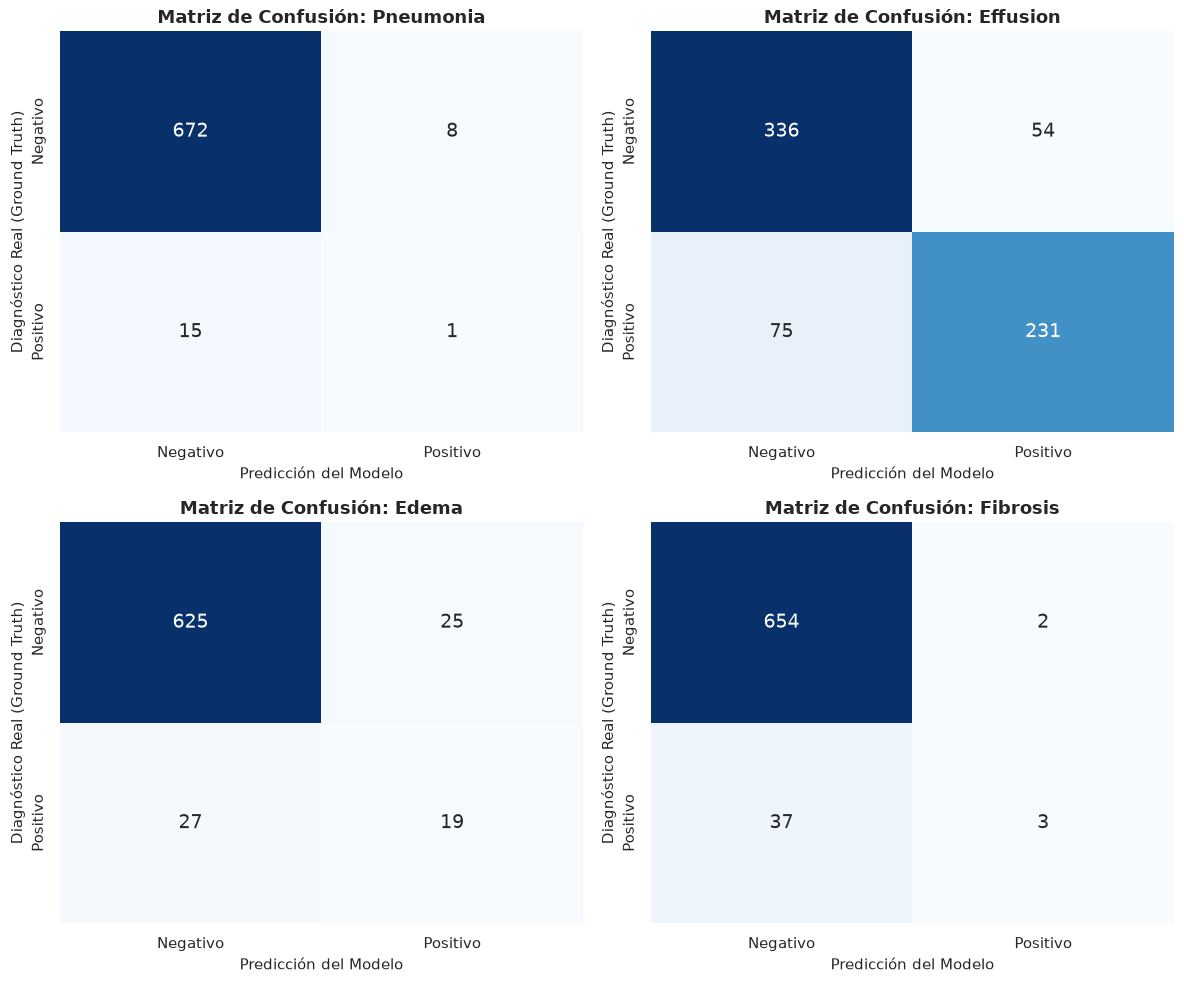

[*] Generando Curvas Precision-Recall (PR-AUC)...


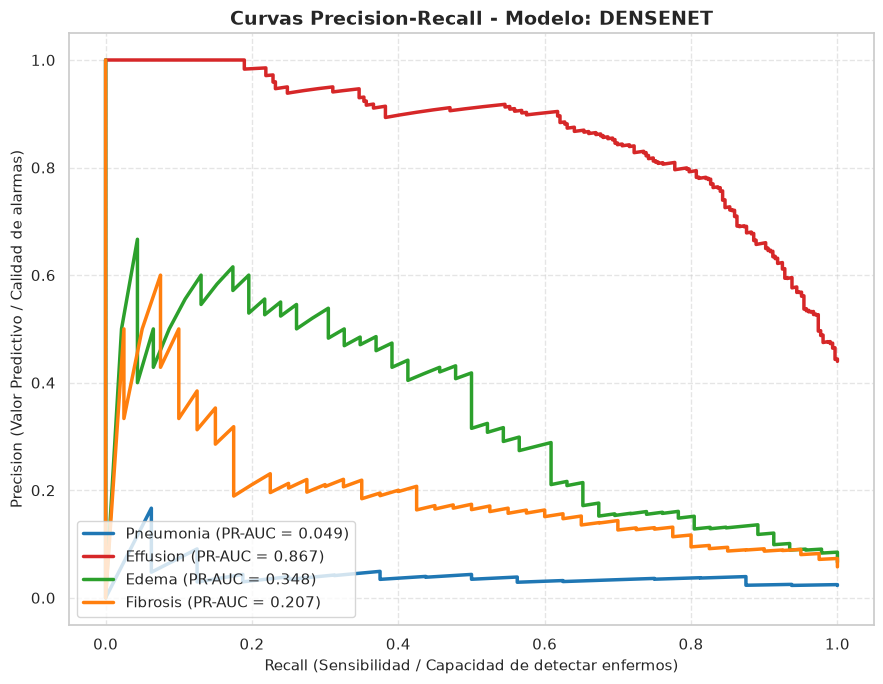

[*] Dashboard de evaluación avanzado completado con éxito.


In [9]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import multilabel_confusion_matrix, precision_recall_curve, average_precision_score
import os

print("[*] Iniciando Dashboard de Auditoría Clínica Avanzada...")

# 1. IDENTIFICAR AL MODELO GANADOR BASADO EN TU CSV DE LA CELDA 7
archivo_metricas = 'metricas_comparativas.csv'
if not os.path.exists(archivo_metricas):
    raise FileNotFoundError(f"[!] No se encontró {archivo_metricas}. Asegúrate de ejecutar la Celda 7 primero.")

df_resultados = pd.read_csv(archivo_metricas)
# Encontramos el modelo con el mejor F1-Score en la validación
modelo_ganador_nombre = df_resultados.sort_values(by='Test F1-Score', ascending=False).iloc[0]['Modelo'].lower()
print(f"[*] Modelo ganador detectado para auditoría: {modelo_ganador_nombre.upper()}")

# 2. INSTANCIAR Y CARGAR LOS PESOS DEL GANADOR
# Reutiliza la función get_model y el device que definiste en la Celda 7
modelo_eval = get_model(modelo_ganador_nombre, num_classes=4)
pesos_path = f"{modelo_ganador_nombre}_best_model.pth"

if not os.path.exists(pesos_path):
    raise FileNotFoundError(f"[!] No se encontraron los pesos en {pesos_path}. Verifica la Celda 7.")

modelo_eval.load_state_dict(torch.load(pesos_path, map_location=device))
modelo_eval.to(device)
modelo_eval.eval()

# 3. EXTRACCIÓN DE PROBABILIDADES PUREZA (INFERENCIA)
print("[*] Extrayendo predicciones del conjunto de Validación...")
all_probs = []
all_labels = []

with torch.no_grad():
    for inputs, labels in dataloaders['val']:
        inputs = inputs.to(device)
        outputs = modelo_eval(inputs)
        probs = torch.sigmoid(outputs) # Probabilidades continuas (0 a 1) por cada patología
        
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.numpy())

all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
all_preds = (all_probs >= 0.5).astype(int) # Umbral de clasificación estándar

patologias = ['Pneumonia', 'Effusion', 'Edema', 'Fibrosis']

# 4. GRAFICAR MATRICES DE CONFUSIÓN MULTIETIQUETA (2x2 por enfermedad)
print("[*] Generando sub-matrices de confusión...")
mcm = multilabel_confusion_matrix(all_labels, all_preds)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for i, conf_matrix in enumerate(mcm):
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False,
                xticklabels=['Negativo', 'Positivo'], yticklabels=['Negativo', 'Positivo'],
                annot_kws={"size": 14})
    axes[i].set_title(f'Matriz de Confusión: {patologias[i]}', fontsize=13, weight='bold')
    axes[i].set_xlabel('Predicción del Modelo', fontsize=11)
    axes[i].set_ylabel('Diagnóstico Real (Ground Truth)', fontsize=11)

plt.tight_layout()
plt.show()

# 5. GRAFICAR CURVAS PRECISION-RECALL (Cruciales para datasets médicos desbalanceados)
print("[*] Generando Curvas Precision-Recall (PR-AUC)...")
fig, ax = plt.subplots(figsize=(9, 7))
colores = ['#1f77b4', '#d62728', '#2ca02c', '#ff7f0e']

for i in range(4):
    precision, recall, _ = precision_recall_curve(all_labels[:, i], all_probs[:, i])
    pr_auc = average_precision_score(all_labels[:, i], all_probs[:, i])
    
    ax.plot(recall, precision, color=colores[i], lw=2.5, 
            label=f'{patologias[i]} (PR-AUC = {pr_auc:.3f})')

ax.set_xlabel('Recall (Sensibilidad / Capacidad de detectar enfermos)', fontsize=11)
ax.set_ylabel('Precision (Valor Predictivo / Calidad de alarmas)', fontsize=11)
ax.set_title(f'Curvas Precision-Recall - Modelo: {modelo_ganador_nombre.upper()}', fontsize=14, weight='bold')
ax.legend(loc='lower left', fontsize=11)
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print("[*] Dashboard de evaluación avanzado completado con éxito.")

## 9. Comparativa Visual de Interpretabilidad (XAI): Grad-CAM Multi-Modelo
Esta celda final implementa una comparativa visual avanzada mediante la técnica Grad-CAM para auditar el proceso de toma de decisiones de las distintas arquitecturas entrenadas. Al generar mapas de calor explicativos para ResNet, DenseNet y EfficientNet de forma simultánea sobre una misma radiografía, el sistema permite contrastar las regiones anatómicas que cada modelo prioriza para su diagnóstico. Este análisis comparativo es fundamental para validar la coherencia clínica de los modelos, identificar sesgos arquitectónicos y demostrar empíricamente cuál de las redes neuronales logra localizar con mayor precisión las anomalías pulmonares.

[*] Iniciando Comparador Visual XAI (ResNet vs DenseNet vs EfficientNet)...


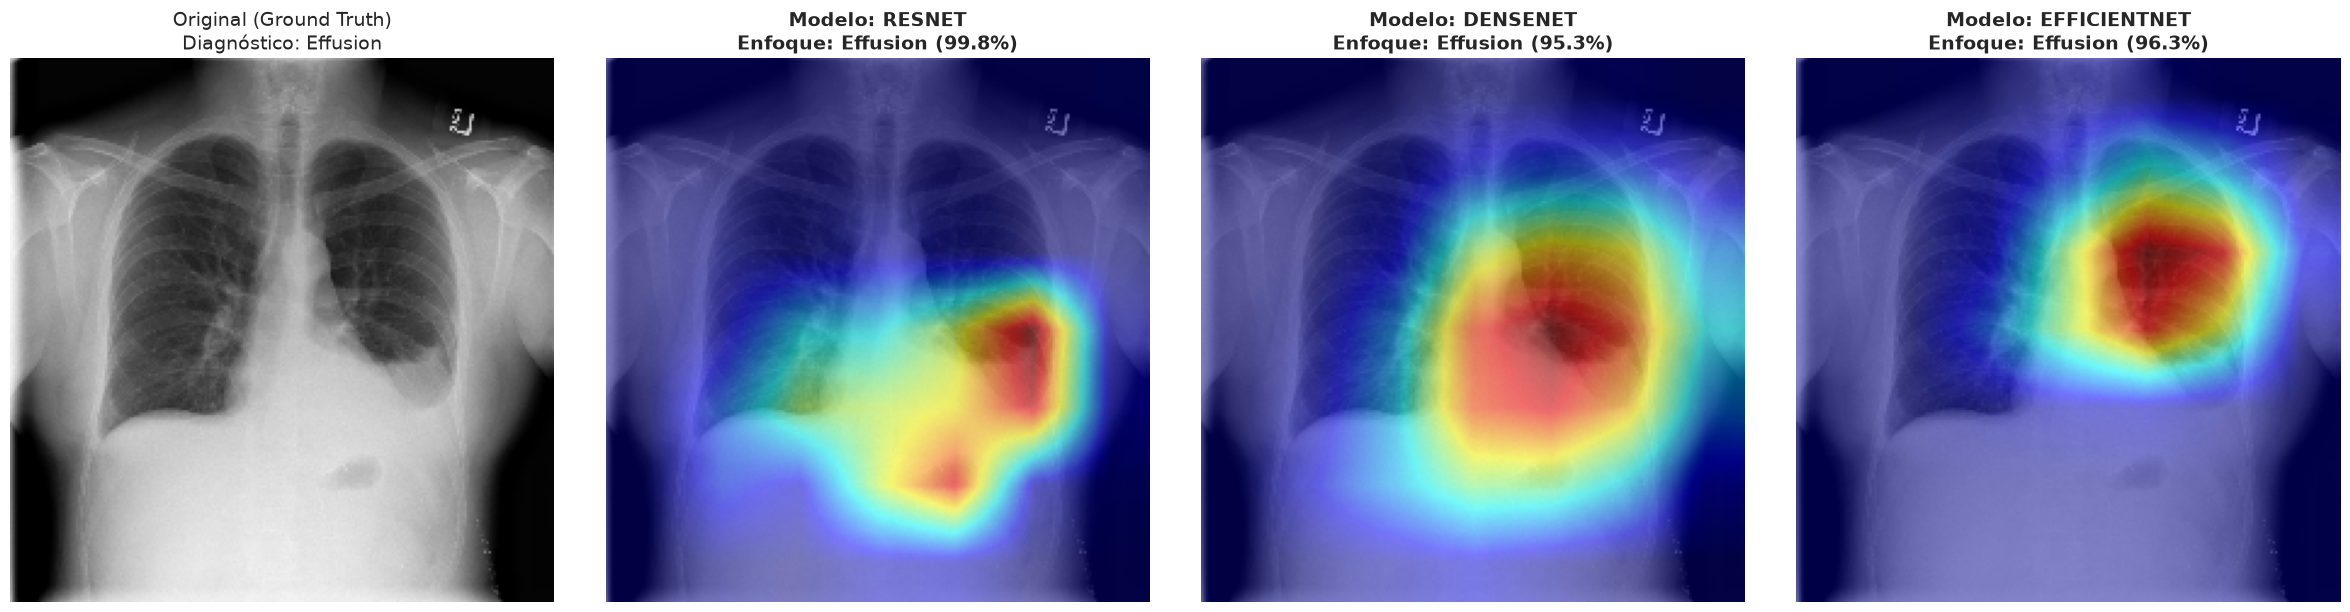

[*] Análisis Comparativo XAI completado para la imagen: 00010456_010.png


In [24]:
import torch
import torch.nn as nn
from torchvision import models, transforms
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os
import random
import pandas as pd
from PIL import Image

# Librerías de Interpretabilidad
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

print("[*] Iniciando Comparador Visual XAI (ResNet vs DenseNet vs EfficientNet)...")

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
patologias = ['Pneumonia', 'Effusion', 'Edema', 'Fibrosis']
num_classes = len(patologias)

# 1. Función unificada para cargar cualquier CNN
def cargar_modelo_xai(nombre, weights_path):
    if nombre == 'resnet':
        model = models.resnet50(weights=None)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
        target_layer = [model.layer4[-1]]
    elif nombre == 'densenet':
        model = models.densenet121(weights=None)
        model.classifier = nn.Linear(model.classifier.in_features, num_classes)
        target_layer = [model.features[-1]]
    elif nombre == 'efficientnet':
        model = models.efficientnet_b0(weights=None)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
        target_layer = [model.features[-1]]
    else:
        return None, None
        
    model.load_state_dict(torch.load(weights_path, map_location=device))
    model.to(device)
    model.eval()
    return model, target_layer

# 2. Seleccionar UN paciente enfermo aleatorio
df_maestro = pd.read_csv('dataset_multietiqueta.csv')
df_test = df_maestro[(df_maestro['Conjunto'] == 'test') & (df_maestro['Es_Sano'] == 0)].reset_index(drop=True)
fila = df_test.iloc[random.randint(0, len(df_test) - 1)]

img_path = fila['Ruta_Ligera']
etiquetas_reales = [pat for pat in patologias if fila[pat] == 1]
label_real_str = " | ".join(etiquetas_reales)

# 3. Preprocesamiento de la imagen compartida
transform_tensor = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
img_pil = Image.open(img_path).convert('RGB')
input_tensor = transform_tensor(img_pil).unsqueeze(0).to(device)
img_rgb = np.array(img_pil, dtype=np.float32) / 255.0

# 4. Bucle Comparativo de Modelos
modelos_a_comparar = ['resnet', 'densenet', 'efficientnet']
resultados_visuales = []

for nombre in modelos_a_comparar:
    pesos_path = f"{nombre}_best_model.pth"
    if not os.path.exists(pesos_path):
        print(f"[!] Omitiendo {nombre}: No se encontró {pesos_path}")
        continue
        
    modelo, target_layers = cargar_modelo_xai(nombre, pesos_path)
    
    # Inferencia
    with torch.no_grad():
        output = modelo(input_tensor)
        probs = torch.sigmoid(output)[0]
        
    # Usar la clase con mayor probabilidad para el Grad-CAM
    target_class_idx = torch.argmax(probs).item()
    targets = [ClassifierOutputTarget(target_class_idx)]
    
    # Generar Grad-CAM
    cam = GradCAM(model=modelo, target_layers=target_layers)
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]
    visualization = show_cam_on_image(img_rgb, grayscale_cam, use_rgb=True)
    
    resultados_visuales.append({
        'nombre': nombre.upper(),
        'imagen': visualization,
        'clase_objetivo': patologias[target_class_idx],
        'confianza': probs[target_class_idx].item() * 100
    })

# 5. Renderizar el Mega-Panel Comparativo
num_plots = len(resultados_visuales) + 1
fig, axes = plt.subplots(1, num_plots, figsize=(6 * num_plots, 6))

# Dibujar la original
axes[0].imshow(img_rgb)
axes[0].set_title(f'Original (Ground Truth)\nDiagnóstico: {label_real_str}', fontsize=14)
axes[0].axis('off')

# Dibujar los mapas de calor de cada modelo
for i, res in enumerate(resultados_visuales):
    ax = axes[i + 1]
    ax.imshow(res['imagen'])
    ax.set_title(f"Modelo: {res['nombre']}\nEnfoque: {res['clase_objetivo']} ({res['confianza']:.1f}%)", fontsize=14, weight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()

print(f"[*] Análisis Comparativo XAI completado para la imagen: {os.path.basename(img_path)}")